# 06 — DMRG Comparison (TeNPy)

> **spinq-vqe** | ARPA Quantum Logical Systems (QONDRA)

Exact diagonalization (ED) is the gold-standard classical benchmark for small Kagome
strips, but its Hilbert space grows as $2^N$. Physical Review–level claims about VQE
on frustrated magnets require a **polynomial-scaling** classical reference — DMRG.

This notebook builds that reference with [TeNPy](https://github.com/tenpy/tenpy)
(`physics-tenpy`) on the same 1D Kagome strip and Hamiltonian used in NB01–NB05.

**Install:** `pip install -e ".[dmrg]"`  
**Regenerate committed artifacts:** `python scripts/run_dmrg_benchmark.py`

## What this establishes

| Check | Purpose |
|-------|---------|
| Hamiltonian match | TeNPy MPO reproduces the PennyLane ED matrix |
| N=9 validation | DMRG $E_0$ matches ED to < 0.01% |
| N=12, 18, 24 | Reference energies beyond sparse-ED comfort |
| $\chi$ convergence (N=18) | Bond-dimension residual certificate (unavailable for VQE) |
| Entanglement profile | DMRG MPS vs VQE statevector in **bits** (NB03) |

### References
- Yan, Huse & White (2011) Science 332 — DMRG spin liquid on Kagome
- Depenbrock, McCulloch & Schollwöck (2012) PRL 109 — nature of the Kagome spin liquid
- Hauschild & Pollmann (2018) SciPost Phys. Lect. Notes — TeNPy documentation


In [ ]:
from __future__ import annotations
import csv
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from spinq_vqe import dmrg, entanglement

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data', exist_ok=True)

REPO = Path('..').resolve()
DATA = REPO / 'data'
FIG = REPO / 'figures'

N_CELLS = [3, 4, 6, 8]
# N=9 is exact at chi~4; use N=18 where truncation is nontrivial.
CHI_SWEEP_N_CELLS = 6
CHI_SWEEP = [8, 16, 32, 64, 128, 200, 300, 400]
CHI_MAX = 400


---
## 1. Validate Hamiltonian against PennyLane ED

The TeNPy MPO must encode the **same** normalized Heisenberg strip as
`kagome.heisenberg_kagome_hamiltonian` (one coupling term per Kagome graph edge,
not a naïve nearest-neighbour chain). We densify both operators at N=9 and check
the element-wise difference.


In [2]:
max_diff = dmrg.validate_hamiltonian_against_pennylane(3)
print(f'max |H_tenpy - H_pennylane| at N=9: {max_diff:.3e}')

max |H_tenpy - H_pennylane| at N=9: 1.110e-16


---
## 2. DMRG ground-state energies

Finite-chain DMRG at $\chi_{\mathrm{max}}=400$ for N = 9, 12, 18, 24 sites
($n_{\mathrm{cells}} = 3,4,6,8$). Energies are **normalized per site**, matching
`data/ed_reference_energies.csv` / NB01.

Results are written to `data/dmrg_reference_energies.csv` for NB05 and the README.


In [3]:
results = []
for n_cells in N_CELLS:
    res = dmrg.run_dmrg(n_cells, chi_max=CHI_MAX, compute_entropies=(n_cells == 3))
    results.append(res)
    print(
        f'N={res.n_sites:>2}  E0={res.e0:.8f}  chi={res.chi}  trunc={res.truncation_error:.2e}'
    )

csv_path = dmrg.save_dmrg_reference_csv(results, DATA / 'dmrg_reference_energies.csv')
print(f'Saved -> {csv_path.name}')

N= 9  E0=-1.42190399  chi=4  trunc=0.00e+00


N=12  E0=-1.48041803  chi=16  trunc=0.00e+00


N=18  E0=-1.49962859  chi=128  trunc=0.00e+00


N=24  E0=-1.50936790  chi=400  trunc=0.00e+00
Saved -> dmrg_reference_energies.csv


---
## 3. Comparison table: ED vs DMRG vs VQE

VQE best energies come from `data/vqe_scaling.csv` (NB02 / NB05). Errors are quoted
**relative to DMRG** once the classical reference exists — ED and DMRG agree to
machine precision where both are available.


In [4]:
def _load_csv_energy(path, key_n, key_e):
    out = {}
    with path.open(newline='', encoding='utf-8') as handle:
        for row in csv.DictReader(handle):
            out[int(row[key_n])] = float(row[key_e])
    return out

ed = _load_csv_energy(DATA / 'ed_reference_energies.csv', 'n_sites', 'E0_normalized')
dmrg_e = {r.n_sites: r.e0 for r in results}
vqe = {}
with (DATA / 'vqe_scaling.csv').open(newline='', encoding='utf-8') as handle:
    for row in csv.DictReader(handle):
        if row['E_VQE'] not in ('N/A', ''):
            vqe[int(row['N'])] = float(row['E_VQE'])

rows = []
for n in [9, 12, 18, 24]:
    e_ed = ed.get(n)
    e_dmrg = dmrg_e.get(n)
    e_vqe = vqe.get(n)
    err = None if e_vqe is None or e_dmrg is None else abs(e_vqe - e_dmrg) / abs(e_dmrg) * 100
    rows.append({
        'N': n,
        'ED E0': f'{e_ed:.4f}' if e_ed is not None else '—',
        'DMRG E0': f'{e_dmrg:.4f}' if e_dmrg is not None else '—',
        'VQE E0': f'{e_vqe:.4f}' if e_vqe is not None else '—',
        'VQE err vs DMRG (%)': f'{err:.2f}' if err is not None else '—',
    })
df = pd.DataFrame(rows)
display(df)

,N,ED E0,DMRG E0,VQE E0,VQE err vs DMRG (%)
0,9,-1.4219,-1.4219,-1.2846,9.66
1,12,—,-1.4804,-1.2386,16.33
2,18,-1.4996,-1.4996,—,—
3,24,—,-1.5094,—,—


---
## 4. $\chi$ convergence (N=18)

At N=9 the strip is essentially exact already at $\chi \approx 4$, so energy-vs-$\chi$
is flat and not a useful certificate. At **N=18** truncation is nontrivial: the left
panel shows $E_0(\chi)$; the right panel shows the residual
$|E_0(\chi) - E_0(\chi_{\mathrm{max}})|$ on a log scale.

→ Saved to `figures/dmrg_chi_convergence.png`


final DMRG state not in canonical form up to norm_tol=1.00e-05: norm_err=1.09e-03


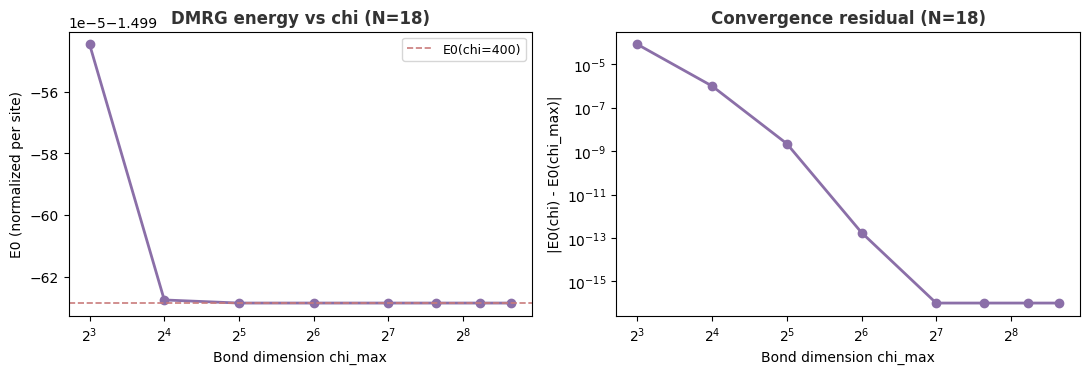

In [5]:
n_chi = 3 * CHI_SWEEP_N_CELLS
chi_results = dmrg.run_dmrg_chi_sweep(CHI_SWEEP_N_CELLS, CHI_SWEEP, max_sweeps=60)
e_ref = chi_results[-1].e0
chis = [r.chi_max for r in chi_results]
residuals = [max(abs(r.e0 - e_ref), 1e-16) for r in chi_results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(chis, [r.e0 for r in chi_results], 'o-', color='#8B6FA8', lw=2, ms=6)
ax.axhline(e_ref, color='#C97B7B', ls='--', lw=1.2, label=f'E0(chi={CHI_MAX})')
ax.set_xlabel('Bond dimension chi_max')
ax.set_ylabel('E0 (normalized per site)')
ax.set_title(f'DMRG energy vs chi (N={n_chi})', fontweight='semibold', color='#333')
ax.set_xscale('log', base=2)
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(chis, residuals, 'o-', color='#8B6FA8', lw=2, ms=6)
ax.set_xlabel('Bond dimension chi_max')
ax.set_ylabel('|E0(chi) - E0(chi_max)|')
ax.set_title(f'Convergence residual (N={n_chi})', fontweight='semibold', color='#333')
ax.set_xscale('log', base=2)
plt.tight_layout()
plt.savefig(FIG / 'dmrg_chi_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Entanglement: DMRG MPS vs VQE statevector

TeNPy returns von Neumann entropy in nats; `spinq_vqe.dmrg` converts to **bits**
($\log_2$) to match NB03. The VQE overlay uses the half-chain convention
($|A| \le N/2$) from `entanglement.entanglement_profile` — full-chain RDMs on the
approximate VQE statevector are numerically unreliable beyond that.

Agreement at cuts 1–2 and divergence at 3–4 is expected: the VQE state is still
~$10\%$ above the true $E_0$.

→ Saved to `figures/dmrg_entanglement_profile.png`


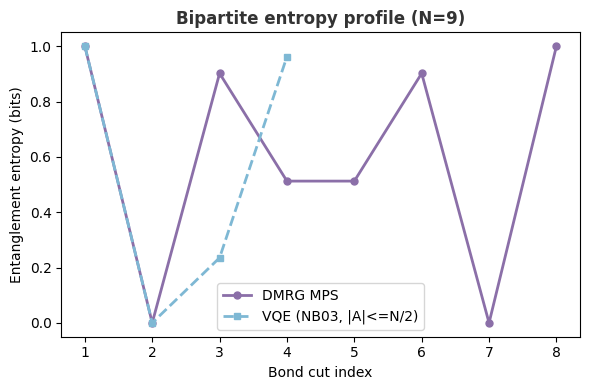

In [6]:
# DMRG entropies are in bits (converted from TeNPy nats in dmrg.run_dmrg).
# VQE overlay uses NB03 half-chain convention (|A| <= N/2); full-chain VQE RDMs
# are numerically unreliable for this approximate statevector.
n9 = next(r for r in results if r.n_sites == 9)
cuts = list(range(1, n9.n_sites))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cuts, n9.entropies, 'o-', color='#8B6FA8', lw=2, ms=5, label='DMRG MPS')
sv_path = DATA / 'statevector_hea_best.npy'
if sv_path.exists():
    sv = np.load(sv_path)
    profile = entanglement.entanglement_profile(sv, n9.n_sites)
    ax.plot(
        profile['subsystem_sizes'],
        profile['entropies'],
        's--',
        color='#7EB8D4',
        lw=2,
        ms=5,
        label='VQE (NB03, |A|<=N/2)',
    )
else:
    print('Note: run NB02 first for VQE statevector overlay.')
ax.set_xlabel('Bond cut index')
ax.set_ylabel('Entanglement entropy (bits)')
ax.set_title('Bipartite entropy profile (N=9)', fontweight='semibold', color='#333')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'dmrg_entanglement_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. ED / DMRG / VQE comparison figure

Bar chart across system sizes. Missing bars mean that method was not run (or not
committed) for that $N$ — e.g. no VQE at N=18/24, no ED at N=24.

→ Saved to `figures/dmrg_vqe_comparison.png`


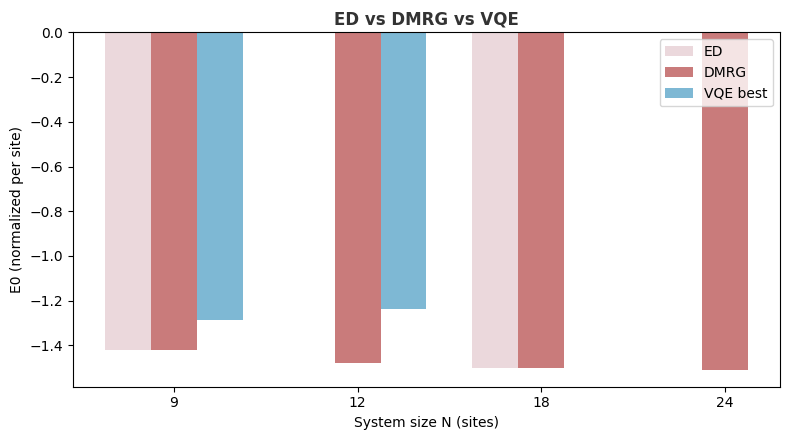

Regenerate all NB06 figures via: python scripts/run_dmrg_benchmark.py


In [7]:
sizes = sorted(set(ed) | set(vqe) | set(dmrg_e))
x = np.arange(len(sizes))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - width, [ed.get(n, np.nan) for n in sizes], width, label='ED', color='#EBD8DC')
ax.bar(x, [dmrg_e.get(n, np.nan) for n in sizes], width, label='DMRG', color='#C97B7B')
ax.bar(x + width, [vqe.get(n, np.nan) for n in sizes], width, label='VQE best', color='#7EB8D4')
ax.set_xticks(x, [str(n) for n in sizes])
ax.set_xlabel('System size N (sites)')
ax.set_ylabel('E0 (normalized per site)')
ax.set_title('ED vs DMRG vs VQE', fontweight='semibold', color='#333')
ax.legend()
plt.tight_layout()
plt.savefig(FIG / 'dmrg_vqe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Regenerate all NB06 figures via: python scripts/run_dmrg_benchmark.py')

---
## Takeaways

1. **TeNPy DMRG matches PennyLane ED** at N=9 (Hamiltonian and $E_0$).
2. **DMRG extends the reference** to N=12, 18, 24 with a $\chi$-convergence certificate.
3. **VQE errors should be quoted vs DMRG** for sizes beyond ED (NB05 / README).
4. Entanglement profiles differ where the variational state is still approximate —
   useful as a diagnostic, not as a claim that VQE has found the spin-liquid wavefunction.

Regenerate all committed NB06 artifacts without opening Jupyter:

```bash
pip install -e ".[dmrg]"
python scripts/run_dmrg_benchmark.py
```

*spinq-vqe / ARPA QONDRA — Notebook 06*
